# Keras Squat Classifier — LSTM
Uses MediaPipe Pose to extract landmarks from video frames, then trains an LSTM
neural network on sequences of 20 consecutive frames.

Feeding sequences instead of single frames lets the model learn the *direction
of movement* — distinguishing between lowering into a squat and standing back up
even when the knee angle looks the same in both directions.

**Pipeline:**
1. MediaPipe extracts pose landmarks per frame
2. Only relevant landmarks + computed angles kept (24 features)
3. Frames grouped into sliding windows of 20; transition windows discarded
4. LSTM model trained on the sequences
5. Exported as `.keras`, `.tflite`, and `.onnx`

In [1]:
%pip install mediapipe opencv-python numpy tensorflow scikit-learn kagglehub tf2onnx

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Step 1 — Setup

In [2]:
import cv2
import mediapipe as mp
import numpy as np
import os
import json
import shutil
import urllib.request
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

MODEL_PATH = os.path.join(os.getcwd(), 'pose_landmarker.task')

if not os.path.exists(MODEL_PATH):
    print('Downloading pose landmarker model...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task',
        MODEL_PATH
    )
    print('Done.')
else:
    print(f'Model found: {MODEL_PATH}')

SEQUENCE_LENGTH = 20

RELEVANT_IDX   = [11, 23, 24, 25, 26, 27, 28]
LEFT_SHOULDER  = 11
LEFT_HIP,  RIGHT_HIP   = 23, 24
LEFT_KNEE, RIGHT_KNEE  = 25, 26
LEFT_ANKLE,RIGHT_ANKLE = 27, 28

SQUAT_CONFIG = {
    'squat_knee_threshold':    120,
    'standing_knee_threshold': 150,
    'visibility_threshold':    0.6,
}

CLASS_NAMES = ['Standing (0)', 'Squat (1)']

def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc  = a - b, c - b
    cosine  = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

def extract_features(landmarks):
    # Symmetric labeling: both squat and standing conditions use avg knee angle only.
    # Previous version had: squat = knee < 120 AND hip < 130 (asymmetric with standing).
    def get(idx):
        p = landmarks[idx]
        return [p.x, p.y], p.visibility

    sh_l, v1 = get(LEFT_SHOULDER)
    hi_l, v2 = get(LEFT_HIP)
    hi_r, v3 = get(RIGHT_HIP)
    kn_l, v4 = get(LEFT_KNEE)
    kn_r, v5 = get(RIGHT_KNEE)
    an_l, v6 = get(LEFT_ANKLE)
    an_r, v7 = get(RIGHT_ANKLE)

    if min(v1, v2, v3, v4, v5, v6, v7) < SQUAT_CONFIG['visibility_threshold']:
        return -1, None, None

    knee_l   = calculate_angle(hi_l, kn_l, an_l)
    knee_r   = calculate_angle(hi_r, kn_r, an_r)
    hip_l    = calculate_angle(sh_l, hi_l, kn_l)
    avg_knee = (knee_l + knee_r) / 2

    coords   = [v for idx in RELEVANT_IDX
                  for v in (landmarks[idx].x, landmarks[idx].y, landmarks[idx].visibility)]
    features = coords + [knee_l, knee_r, hip_l]   # 21 + 3 = 24

    if avg_knee < SQUAT_CONFIG['squat_knee_threshold']:
        label = 1
    elif avg_knee > SQUAT_CONFIG['standing_knee_threshold']:
        label = 0
    else:
        label = -1

    return label, features, avg_knee

FEATURE_SIZE = len(RELEVANT_IDX) * 3 + 3   # 24
print(f'Setup complete. Features per frame: {FEATURE_SIZE}, Sequence length: {SEQUENCE_LENGTH}')


Model found: c:\Users\gusta\Desktop\SkoleCoding\ML_NODE_EXAM\PulseML.js\ML\Squats\pose_landmarker.task
Setup complete. Features per frame: 24, Sequence length: 20


## Step 2 — Download training videos from Kaggle

In [3]:
import kagglehub

VIDEOS_DIR = os.path.join(os.getcwd(), 'trainingData', 'videos')
os.makedirs(VIDEOS_DIR, exist_ok=True)

dataset_path = kagglehub.dataset_download('hasyimabdillah/workoutfitness-video')
print('Downloaded to:', dataset_path)

squat_folder = os.path.join(dataset_path, 'squat')
if not os.path.exists(squat_folder):
    for root, dirs, files in os.walk(dataset_path):
        if os.path.basename(root).lower() == 'squat':
            squat_folder = root
            break

print('Squat folder:', squat_folder)

for fname in os.listdir(squat_folder):
    if fname.endswith(('.mp4', '.mov', '.avi')):
        src = os.path.join(squat_folder, fname)
        dst = os.path.join(VIDEOS_DIR, fname)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
            print(f'Copied: {fname}')
        else:
            print(f'Already exists: {fname}')

print(f'\nTotal videos ready: {len(os.listdir(VIDEOS_DIR))}')

C:\Users\gusta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: C:\Users\gusta\.cache\kagglehub\datasets\hasyimabdillah\workoutfitness-video\versions\5
Squat folder: C:\Users\gusta\.cache\kagglehub\datasets\hasyimabdillah\workoutfitness-video\versions\5\squat
Already exists: squat_10.mp4
Already exists: squat_11.mp4
Already exists: squat_12.mp4
Already exists: squat_13.mp4
Already exists: squat_14.mp4
Already exists: squat_15.mp4
Already exists: squat_16.mp4
Already exists: squat_17.mp4
Already exists: squat_18.mp4
Already exists: squat_19.mp4
Already exists: squat_20.mp4
Already exists: squat_21.mp4
Already exists: squat_22.mp4
Already exists: squat_23.mp4
Already exists: squat_24.mp4
Already exists: squat_25.mp4
Already exists: squat_26.mp4
Already exists: squat_27.mp4
Already exists: squat_28.mp4
Already exists: squat_29.mp4
Already exists: squat_7.mp4
Already exists: squat_8.mp4
Already exists: squat_9.mp4

Total videos ready: 23


## Step 3 — Extract and auto-label frames

In [4]:
VIDEO_PATHS = [
    os.path.join(VIDEOS_DIR, f)
    for f in os.listdir(VIDEOS_DIR)
    if f.endswith(('.mp4', '.mov', '.avi'))
]
print(f'Found {len(VIDEO_PATHS)} videos')

def process_video(video_path):
    # Uses the video's actual FPS for timestamps so MediaPipe timing is correct.
    raw = []
    cap = cv2.VideoCapture(video_path)
    total        = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS) or 30.0
    ms_per_frame = 1000.0 / fps
    base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
    options = mp_vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=mp_vision.RunningMode.VIDEO,
    )
    timestamp_ms = 0
    processed    = 0
    with mp_vision.PoseLandmarker.create_from_options(options) as landmarker:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            timestamp_ms += int(ms_per_frame)
            rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result   = landmarker.detect_for_video(mp_image, timestamp_ms)
            if result.pose_landmarks:
                label, features, _ = extract_features(result.pose_landmarks[0])
                if label != -1 and features is not None:
                    raw.append((features, label))
                else:
                    raw.append(None)
            else:
                raw.append(None)
            processed += 1
            if processed % 100 == 0:
                print(f'  {processed}/{total} frames')
    cap.release()

    X, y = [], []
    for i in range(len(raw) - SEQUENCE_LENGTH + 1):
        window = raw[i:i + SEQUENCE_LENGTH]
        if None in window:
            continue
        feats  = [f for f, l in window]
        labels = [l for f, l in window]
        if len(set(labels)) == 1:
            X.append(feats)
            y.append(labels[-1])
    return X, y


# ── Feature-space augmentation ───────────────────────────────────────────────
# Squat feature layout (24 values per frame):
#   [0-2]   L_shoulder  (x, y, vis)
#   [3-5]   L_hip       (x, y, vis)
#   [6-8]   R_hip       (x, y, vis)
#   [9-11]  L_knee      (x, y, vis)
#   [12-14] R_knee      (x, y, vis)
#   [15-17] L_ankle     (x, y, vis)
#   [18-20] R_ankle     (x, y, vis)
#   [21]    knee_l angle
#   [22]    knee_r angle
#   [23]    hip_l angle
def mirror_squat_sequence(seq):
    mirrored = seq.copy()
    # L_shoulder (0-2) has no R counterpart — just flip its x
    mirrored[:, 0] = 1.0 - seq[:, 0]
    # swap paired triplets and flip x
    for lo, hi in [(3, 6), (9, 12), (15, 18)]:
        mirrored[:, lo]   = 1.0 - seq[:, hi]    # x
        mirrored[:, hi]   = 1.0 - seq[:, lo]    # x
        mirrored[:, lo+1] = seq[:, hi+1]         # y
        mirrored[:, hi+1] = seq[:, lo+1]         # y
        mirrored[:, lo+2] = seq[:, hi+2]         # vis
        mirrored[:, hi+2] = seq[:, lo+2]         # vis
    # swap L/R knee angles; hip_l stays as best approximation of hip_r
    mirrored[:, 21] = seq[:, 22]
    mirrored[:, 22] = seq[:, 21]
    return mirrored

def add_noise(seq, sigma=0.005):
    return seq + np.random.normal(0, sigma, seq.shape).astype(np.float32)

def augment(X, y, noise_copies=2):
    X_arr = np.array(X, dtype=np.float32)
    X_mir = np.array([mirror_squat_sequence(s) for s in X_arr])
    parts_X = [X_arr, X_mir] + [add_noise(X_arr) for _ in range(noise_copies)]
    parts_y = [y] * len(parts_X)
    return np.concatenate(parts_X), np.concatenate(parts_y)


# ── Split by source video BEFORE windowing/augmentation ─────────────────────
# Sliding windows overlap by 19/20 frames, and augmentation creates near-duplicate
# copies (mirrored / noise-jittered) of each window. Splitting windows directly
# leaks near-identical sequences across train/val/test, inflating test metrics.
# Splitting by video first guarantees train/val/test never share frames from the
# same clip. Only the training split is augmented — val/test stay as real,
# unaugmented sequences from videos the model has never seen.
#
# With only ~23 videos, a plain random video split can land all of one class's
# videos in train and leave val/test with a single class. We process each video
# once, then split videos stratified by each video's majority window label so
# both classes are represented in every split.
from sklearn.model_selection import train_test_split

video_data = []
for path in VIDEO_PATHS:
    print(f'Processing {os.path.basename(path)}...')
    Xv, yv = process_video(path)
    video_data.append((path, Xv, yv))

majority_labels = [int(round(np.mean(yv))) if yv else 0 for _, _, yv in video_data]

train_data, temp_data = train_test_split(
    video_data, test_size=0.4, random_state=42, stratify=majority_labels)
temp_majority = [int(round(np.mean(yv))) if yv else 0 for _, _, yv in temp_data]
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_majority)

print(f'Videos — train: {len(train_data)}  val: {len(val_data)}  test: {len(test_data)}')

def build_split(video_data_list, augment_split):
    X_split, y_split = [], []
    for _, Xv, yv in video_data_list:
        X_split.extend(Xv)
        y_split.extend(yv)
    X_split = np.array(X_split, dtype=np.float32)
    y_split = np.array(y_split, dtype=np.int32)
    print(f'  raw sequences: {len(X_split)} — standing: {np.sum(y_split==0)}, squat: {np.sum(y_split==1)}')
    if augment_split:
        X_split, y_split = augment(X_split, y_split)
        print(f'  after augmentation: {len(X_split)} — standing: {np.sum(y_split==0)}, squat: {np.sum(y_split==1)}')
    return X_split, y_split

X_train, y_train = build_split(train_data, augment_split=True)
X_val,   y_val   = build_split(val_data,   augment_split=False)
X_test,  y_test  = build_split(test_data,  augment_split=False)

print(f'\nFinal — train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}')
print(f'Input shape (train): {X_train.shape}')


Found 23 videos
Processing squat_10.mp4...
  100/175 frames
Processing squat_11.mp4...
  100/144 frames
Processing squat_12.mp4...
  100/113 frames
Processing squat_13.mp4...
  100/130 frames
Processing squat_14.mp4...
  100/101 frames
Processing squat_15.mp4...
  100/280 frames
  200/280 frames
Processing squat_16.mp4...
Processing squat_17.mp4...
  100/110 frames
Processing squat_18.mp4...
Processing squat_19.mp4...
  100/143 frames
Processing squat_20.mp4...
  100/233 frames
  200/233 frames
Processing squat_21.mp4...
  100/348 frames
  200/348 frames
  300/348 frames
Processing squat_22.mp4...
  100/380 frames
  200/380 frames
  300/380 frames
Processing squat_23.mp4...
  100/432 frames
  200/432 frames
  300/432 frames
  400/432 frames
Processing squat_24.mp4...
  100/198 frames
Processing squat_25.mp4...
  100/338 frames
  200/338 frames
  300/338 frames
Processing squat_26.mp4...
  100/368 frames
  200/368 frames
  300/368 frames
Processing squat_27.mp4...
  100/647 frames
  200

## Step 4 — Train

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras

# X_train / X_val / X_test (and y_*) were built in the previous cell, split by
# source video before windowing/augmentation.

N_tr, seq_len, n_feat = X_train.shape
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train.reshape(-1, n_feat)).reshape(N_tr, seq_len, n_feat)
X_val_s   = scaler.transform(X_val.reshape(-1, n_feat)).reshape(X_val.shape)
X_test_s  = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape)

INPUT_SIZE = n_feat

class_weights     = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f'Class weights: {class_weight_dict}')

model = keras.Sequential([
    keras.layers.Input(shape=(SEQUENCE_LENGTH, INPUT_SIZE)),
    keras.layers.LSTM(64),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid'),
])

optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

loss, acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f'\nFinal held-out test accuracy: {acc:.4f}  |  loss: {loss:.4f}')

Class weights: {0: np.float64(1.0442176870748299), 1: np.float64(0.959375)}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,897 (97.25 KB)

 Trainable params: 24,897 (97.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9585 - loss: 0.2567 - val_accuracy: 1.0000 - val_loss: 0.1520
Epoch 2/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0194 - val_accuracy: 1.0000 - val_loss: 0.0991
Epoch 3/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 0.0786
Epoch 4/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 0.0665
Epoch 5/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 0.0586
Epoch 6/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 9.1035e-04 - val_accuracy: 1.0000 - val_loss: 0.0548
Epoch 7/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 8.0752e-04 - val_accuracy: 1.0000 - val_loss: 0.0508
Epoch 8/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 7.7730e-04 - val_accuracy

## Step 5 — Evaluate

=== Classification Report ===
              precision    recall  f1-score   support

Standing (0)       1.00      1.00      1.00       135
   Squat (1)       1.00      1.00      1.00        14

    accuracy                           1.00       149
   macro avg       1.00      1.00      1.00       149
weighted avg       1.00      1.00      1.00       149

=== Confusion Matrix ===
[[135   0]
 [  0  14]]
Rows = actual class, Columns = predicted class


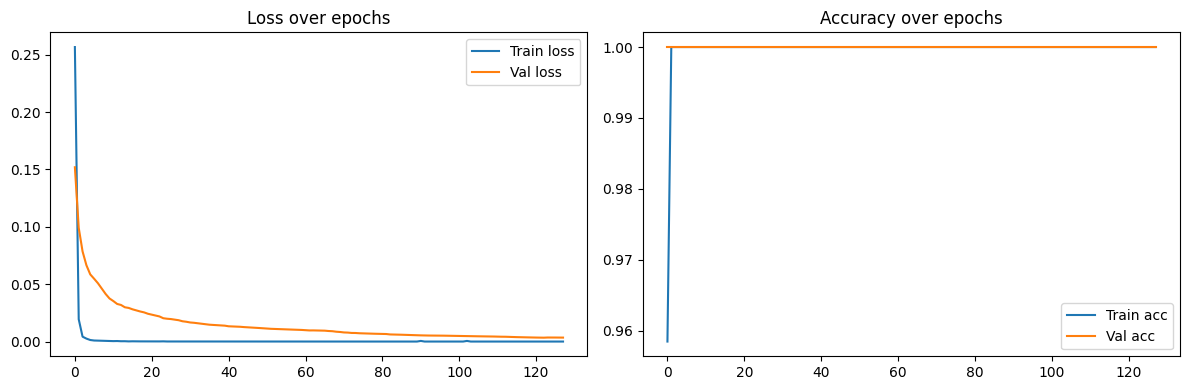

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test_s, verbose=0).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

print('=== Confusion Matrix ===')
cm = confusion_matrix(y_test, y_pred)
print(cm)
print('Rows = actual class, Columns = predicted class')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],         label='Train loss')
ax1.plot(history.history['val_loss'],     label='Val loss')
ax1.set_title('Loss over epochs'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train acc')
ax2.plot(history.history['val_accuracy'], label='Val acc')
ax2.set_title('Accuracy over epochs'); ax2.legend()
plt.tight_layout()
plt.show()

## Step 6 — Export

In [7]:
import tf2onnx, shutil

model.save('squat_model.keras')
print('Exported: squat_model.keras')

scaler_params = {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}
with open('squat_model_scaler.json', 'w') as f:
    json.dump(scaler_params, f)
print('Exported: squat_model_scaler.json')

import subprocess, sys
model.export('onnx_tmp')
result = subprocess.run([
    sys.executable, '-m', 'tf2onnx.convert',
    '--saved-model', 'onnx_tmp',
    '--output', 'squat_model.onnx',
    '--opset', '13',
], capture_output=True, text=True)
shutil.rmtree('onnx_tmp')
if result.returncode != 0:
    print('ONNX error:', result.stderr)
else:
    print('Exported: squat_model.onnx')

Exported: squat_model.keras
Exported: squat_model_scaler.json
INFO:tensorflow:Assets written to: onnx_tmp\assets


INFO:tensorflow:Assets written to: onnx_tmp\assets


Saved artifact at 'onnx_tmp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 24), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2551929629456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2551929511120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2551929575504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2551929575120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2551929629840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2551929573776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2551929629648: TensorSpec(shape=(), dtype=tf.resource, name=None)
Exported: squat_model.onnx
